# Teacher-Augmented CSBoost vs Baselines on the Give Me Some Credit dataset


In [1]:
# =============================================================================
# IMPORTS & CONFIGURATION
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import stats as scipy_stats

import sklearn
sklearn.set_config(enable_metadata_routing=True)

from sklearn.calibration import calibration_curve
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier
from empulse.datasets import (
    load_give_me_some_credit,
    load_credit_scoring_pakdd,
    load_give_me_some_credit,
    load_upsell_bank_telemarketing,
)
from empulse.metrics import expected_cost_loss
from empulse.models import CSLogitClassifier, CSBoostClassifier

RANDOM_STATE = 42
N_OUTER_FOLDS = 5
N_REPETITIONS = 2
N_INNER_FOLDS = 3
N_JOBS = 1

BASELINE_LOGIT_GRID = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.0, 0.5, 1.0],
}
BASELINE_CSLOGIT_GRID = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.0, 0.5, 1.0],
}
BASELINE_BOOST_GRID = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3],
    'model__min_child_weight': [1, 3, 5],
}
BASELINE_CSBOOST_GRID = {
    'model__estimator__n_estimators': [100, 200],
    'model__estimator__learning_rate': [0.05, 0.1],
    'model__estimator__max_depth': [2, 3],
    'model__estimator__min_child_weight': [1, 3, 5],
}

TEACHER_CSBOOST_GRID = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
}


In [2]:
# =============================================================================
# LOAD DATA
# =============================================================================
dataset = load_give_me_some_credit(as_frame=True)

X = dataset.data.copy()
y = dataset.target.copy()

tp_cost = dataset.tp_cost
fp_cost = dataset.fp_cost
tn_cost = dataset.tn_cost
fn_cost = dataset.fn_cost

print('Dataset: Give Me Some Credit')
print(f'Samples: {len(y):,}')
print(f'Features: {X.shape[1]}')
print(f'Positive rate: {np.mean(y):.2%}')
if hasattr(X, 'isna'):
    missing_by_col = X.isna().sum()
    missing_by_col = missing_by_col[missing_by_col > 0]
    print(f'Total missing values: {int(X.isna().sum().sum())}')
    if len(missing_by_col):
        print('Columns with missing values:')
        print(missing_by_col.sort_values(ascending=False))


Dataset: Give Me Some Credit
Samples: 112,915
Features: 10
Positive rate: 6.74%
Total missing values: 0


Instance-dependent cost structure:


,scalar,value,mean,std,min,q25,median,q75,max
name,,,,,,,,,
tp_cost,True,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fp_cost,False,NaN,863.8126,134.4734,544.9351,751.7338,865.5622,1023.7305,1023.7305
tn_cost,True,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fn_cost,False,NaN,12487.9910,5265.6625,1.5000,8099.2500,12556.5000,18750.0000,18750.0000



FN/FP cost ratio — mean: 13.80, median: 14.51, min: 0.00, max: 18.32


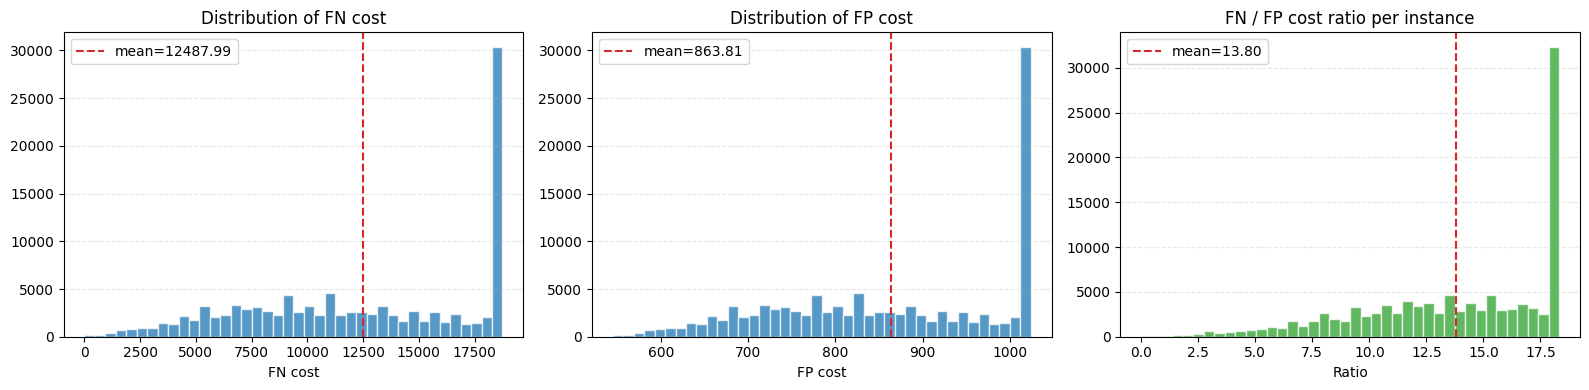

In [3]:
# =============================================================================
# COST STRUCTURE SUMMARY
# =============================================================================
def _cost_summary_series(name, values):
    a = np.asarray(values, dtype=float).ravel()
    if a.ndim == 0 or a.size == 1:
        return pd.Series({'name': name, 'scalar': True, 'value': float(a.flat[0])})
    return pd.Series({
        'name': name, 'scalar': False,
        'mean': float(a.mean()), 'std': float(a.std()),
        'min': float(a.min()), 'q25': float(np.percentile(a, 25)),
        'median': float(np.median(a)), 'q75': float(np.percentile(a, 75)),
        'max': float(a.max()),
    })

cost_info = pd.DataFrame([
    _cost_summary_series('tp_cost', tp_cost),
    _cost_summary_series('fp_cost', fp_cost),
    _cost_summary_series('tn_cost', tn_cost),
    _cost_summary_series('fn_cost', fn_cost),
]).set_index('name')

print('Instance-dependent cost structure:')
display(cost_info.round(4))

fn_arr_tmp = np.asarray(fn_cost, dtype=float).ravel()
fp_arr_tmp = np.asarray(fp_cost, dtype=float).ravel()
if fn_arr_tmp.size > 1 or fp_arr_tmp.size > 1:
    ratio = fn_arr_tmp / (fp_arr_tmp + 1e-12)
    print(f'\nFN/FP cost ratio — mean: {ratio.mean():.2f}, '
          f'median: {np.median(ratio):.2f}, '
          f'min: {ratio.min():.2f}, max: {ratio.max():.2f}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (arr, label) in zip(axes[:2], [(fn_arr_tmp, 'FN cost'), (fp_arr_tmp, 'FP cost')]):
        ax.hist(arr, bins=40, color='tab:blue', alpha=0.75, edgecolor='white')
        ax.axvline(arr.mean(), color='tab:red', linestyle='--', label=f'mean={arr.mean():.2f}')
        ax.set_title(f'Distribution of {label}')
        ax.set_xlabel(label)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.3)
    axes[2].hist(ratio, bins=40, color='tab:green', alpha=0.75, edgecolor='white')
    axes[2].axvline(ratio.mean(), color='tab:red', linestyle='--', label=f'mean={ratio.mean():.2f}')
    axes[2].set_title('FN / FP cost ratio per instance')
    axes[2].set_xlabel('Ratio')
    axes[2].legend()
    axes[2].grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'\nCosts are scalar: FN={float(fn_arr_tmp.flat[0]):.4f}, '
          f'FP={float(fp_arr_tmp.flat[0]):.4f}, '
          f'ratio FN/FP={float(fn_arr_tmp.flat[0])/(float(fp_arr_tmp.flat[0])+1e-12):.2f}')
del fn_arr_tmp, fp_arr_tmp

In [4]:
# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================
def take_idx(arr, idx):
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return arr.item()
    return arr[idx]


def take_rows(X, idx):
    if hasattr(X, 'iloc'):
        return X.iloc[idx].copy()
    return X[idx]


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def build_feature_preprocessor(X_frame):
    if not isinstance(X_frame, pd.DataFrame):
        X_frame = pd.DataFrame(X_frame)

    numeric_columns = X_frame.select_dtypes(include=[np.number, 'bool']).columns.tolist()
    categorical_columns = [col for col in X_frame.columns if col not in numeric_columns]

    transformers = []
    if numeric_columns:
        numeric_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ])
        transformers.append(('num', numeric_pipe, numeric_columns))

    if categorical_columns:
        categorical_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_onehot_encoder()),
        ])
        transformers.append(('cat', categorical_pipe, categorical_columns))

    return ColumnTransformer(transformers=transformers, remainder='drop')


def build_stratify_key(y, fn_cost, fp_cost, n_bins=3):
    """Combine class label with cost-magnitude quantile bins for cost-aware
    stratified CV splits.  Ensures each fold has a representative mix of
    high-cost and low-cost instances, reducing AEC variance across folds."""
    y = np.asarray(y).ravel()
    fn = np.asarray(fn_cost, dtype=float).ravel()
    fp = np.asarray(fp_cost, dtype=float).ravel()
    if fn.size == 1:
        fn = np.full(len(y), fn.item())
    if fp.size == 1:
        fp = np.full(len(y), fp.item())
    mc = np.where(y == 1, fn, fp)
    unique_vals = np.unique(mc)
    if len(unique_vals) <= n_bins:
        cost_bin = np.searchsorted(unique_vals, mc)
    else:
        boundaries = np.percentile(mc, np.linspace(0, 100, n_bins + 1)[1:-1])
        cost_bin = np.digitize(mc, boundaries)
    n_levels = int(cost_bin.max()) + 1
    return (y * n_levels + cost_bin).astype(int)


def compute_cost_weights(y_arr, fp_arr, fn_arr):
    weights = np.where(np.asarray(y_arr) == 1, np.asarray(fn_arr), np.asarray(fp_arr))
    return weights / (np.mean(weights) + 1e-8)


def compute_aec(y_true, y_prob, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=float)
    n = len(y_true)
    tp_arr = np.full(n, tp_cost) if np.isscalar(tp_cost) else np.asarray(tp_cost)
    fp_arr = np.full(n, fp_cost) if np.isscalar(fp_cost) else np.asarray(fp_cost)
    tn_arr = np.full(n, tn_cost) if np.isscalar(tn_cost) else np.asarray(tn_cost)
    fn_arr = np.full(n, fn_cost) if np.isscalar(fn_cost) else np.asarray(fn_cost)
    expected = np.where(
        y_true == 1,
        y_prob * tp_arr + (1 - y_prob) * fn_arr,
        y_prob * fp_arr + (1 - y_prob) * tn_arr,
    )
    return float(np.mean(expected))


def compute_id_thresholds(tp_cost, fp_cost, tn_cost, fn_cost):
    tp_arr = np.asarray(tp_cost, dtype=float)
    fp_arr = np.asarray(fp_cost, dtype=float)
    tn_arr = np.asarray(tn_cost, dtype=float)
    fn_arr = np.asarray(fn_cost, dtype=float)
    denom = (fp_arr - tn_arr) + (fn_arr - tp_arr)
    thresholds = np.divide(
        fp_arr - tn_arr,
        denom,
        out=np.full_like(denom, 0.5, dtype=float),
        where=np.abs(denom) > 1e-12,
    )
    return np.clip(thresholds, 0.0, 1.0)


def predict_with_instance_threshold(y_prob, tp_cost, fp_cost, tn_cost, fn_cost):
    thresholds = compute_id_thresholds(tp_cost, fp_cost, tn_cost, fn_cost)
    y_pred = (np.asarray(y_prob) >= thresholds).astype(int)
    return y_pred, thresholds


def compute_cost_at_decision(y_true, y_pred, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    tp_arr = np.full(n, tp_cost) if np.isscalar(tp_cost) else np.asarray(tp_cost)
    fp_arr = np.full(n, fp_cost) if np.isscalar(fp_cost) else np.asarray(fp_cost)
    tn_arr = np.full(n, tn_cost) if np.isscalar(tn_cost) else np.asarray(tn_cost)
    fn_arr = np.full(n, fn_cost) if np.isscalar(fn_cost) else np.asarray(fn_cost)
    realized = np.where(
        y_true == 1,
        np.where(y_pred == 1, tp_arr, fn_arr),
        np.where(y_pred == 1, fp_arr, tn_arr),
    )
    return float(np.sum(realized))


def compute_trivial_costs(y_true, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    all_zero = np.zeros_like(y_true)
    all_one = np.ones_like(y_true)
    return (
        compute_cost_at_decision(y_true, all_zero, tp_cost, fp_cost, tn_cost, fn_cost),
        compute_cost_at_decision(y_true, all_one, tp_cost, fp_cost, tn_cost, fn_cost),
    )


def compute_savings_vs_no_action(model_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost):
    no_action_cost, _ = compute_trivial_costs(y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    return float((no_action_cost - model_cost) / (no_action_cost + 1e-12))


def compute_savings_vs_best_trivial(model_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost):
    all_neg_cost, all_pos_cost = compute_trivial_costs(y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    best_trivial = min(all_neg_cost, all_pos_cost)
    return float((best_trivial - model_cost) / (best_trivial + 1e-12))


def compute_spearman_costcorr(y_true, y_prob, fn_cost):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    fn_arr = np.asarray(fn_cost)
    severity = y_true * fn_arr
    if np.all(severity == severity[0]):
        return np.nan
    corr, _ = scipy_stats.spearmanr(y_prob, severity)
    return float(corr) if np.isfinite(corr) else np.nan


def evaluate_model(y_true, y_prob, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=float)
    metrics = {
        'AUROC': roc_auc_score(y_true, y_prob),
        'AP': average_precision_score(y_true, y_prob),
        'AEC': compute_aec(y_true, y_prob, tp_cost, fp_cost, tn_cost, fn_cost),
        'Brier': brier_score_loss(y_true, y_prob),
        'Spearman': compute_spearman_costcorr(y_true, y_prob, fn_cost),
    }
    y_pred, thresholds = predict_with_instance_threshold(y_prob, tp_cost, fp_cost, tn_cost, fn_cost)
    realized_cost = compute_cost_at_decision(y_true, y_pred, tp_cost, fp_cost, tn_cost, fn_cost)
    metrics['F1'] = f1_score(y_true, y_pred, zero_division=0)
    metrics['Cost'] = realized_cost
    metrics['Savings_no_action'] = compute_savings_vs_no_action(realized_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    metrics['Savings_best_trivial'] = compute_savings_vs_best_trivial(realized_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    metrics['ID_threshold_mean'] = float(np.mean(thresholds))
    return metrics


def format_results(results, model_name):
    df = pd.DataFrame(results)
    cols = ['AUROC', 'AP', 'AEC', 'Brier', 'F1', 'Cost', 'Savings_no_action', 'Savings_best_trivial', 'Spearman', 'ID_threshold_mean']
    out = {c + '_mean': float(df[c].mean()) for c in cols}
    out.update({c + '_std': float(df[c].std()) for c in cols})
    out['model'] = model_name
    return out


def print_model_summary(model_name, summary):
    print(f'Results for {model_name}:')
    print(f"  AEC: {summary['AEC_mean']:.4f} +/- {summary['AEC_std']:.4f}")
    print(f"  Cost: {summary['Cost_mean']:.2f} +/- {summary['Cost_std']:.2f}")
    print(f"  Savings_no_action: {summary['Savings_no_action_mean']:.4f} +/- {summary['Savings_no_action_std']:.4f}")
    print(f"  AUROC: {summary['AUROC_mean']:.4f} +/- {summary['AUROC_std']:.4f}")


def sanitize_param_name(name):
    return (
        str(name)
        .replace('model__estimator__', '')
        .replace('model__', '')
        .replace('__', '_')
    )


def collect_prediction_rows(model_name, y_true, y_prob, split):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=float)
    n = len(y_true)
    split_id = f"r{split['rep']}_f{split['fold']}"
    return pd.DataFrame({
        'Model': model_name,
        'Rep': split['rep'],
        'Fold': split['fold'],
        'SplitID': split_id,
        'row_in_test_fold': np.arange(n),
        'y_true': y_true.astype(int),
        'y_prob': y_prob,
    }).to_dict('records')


In [5]:
# =============================================================================
# CROSS-VALIDATION SETUP
# =============================================================================
X_data = X.copy() if hasattr(X, 'copy') else pd.DataFrame(X)
FEATURE_PREPROCESSOR = build_feature_preprocessor(X_data)
y_arr = y.values if hasattr(y, 'values') else np.asarray(y)
tp_arr = np.asarray(tp_cost)
fp_arr = np.asarray(fp_cost)
tn_arr = np.asarray(tn_cost)
fn_arr = np.asarray(fn_cost)

stratify_arr = build_stratify_key(y_arr, fn_arr, fp_arr)
print(f'Cost-stratification key: {len(np.unique(stratify_arr))} unique strata '
      f'(class x cost-bin)')

INNER_CV = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = []
for rep in range(N_REPETITIONS):
    outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE + rep)
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_data, stratify_arr), start=1):
        cv_splits.append({'rep': rep + 1, 'fold': fold, 'train_idx': train_idx, 'test_idx': test_idx})

print(f'Generated {len(cv_splits)} outer evaluations')
print(f'  Train: {len(cv_splits[0]["train_idx"])} ({len(cv_splits[0]["train_idx"]) / len(y_arr):.1%})')
print(f'  Test:  {len(cv_splits[0]["test_idx"])} ({len(cv_splits[0]["test_idx"]) / len(y_arr):.1%})')


Cost-stratification key: 6 unique strata (class x cost-bin)
Generated 10 outer evaluations
  Train: 90332 (80.0%)
  Test:  22583 (20.0%)


In [6]:
# =============================================================================
# BASELINE HELPERS
# =============================================================================
class RoutedLogisticRegression(LogisticRegression):
    def fit(self, X, y, tp_cost=None, fp_cost=None, tn_cost=None, fn_cost=None, **fit_params):
        return super().fit(X, y, **fit_params)


class RoutedXGBClassifier(XGBClassifier):
    def fit(self, X, y, tp_cost=None, fp_cost=None, tn_cost=None, fn_cost=None, **fit_params):
        return super().fit(X, y, **fit_params)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'classifier'
        return tags


def build_logit_estimator():
    model = RoutedLogisticRegression(
        penalty='elasticnet',
        l1_ratio=0.5,
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model = model.set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


def build_cslogit_estimator():
    model = CSLogitClassifier().set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


def build_boost_estimator():
    model = RoutedXGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
    )
    model = model.set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


def build_csboost_estimator():
    model = CSBoostClassifier(
        estimator=RoutedXGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
        ),
    ).set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


aec_scorer = make_scorer(
    expected_cost_loss,
    greater_is_better=False,
    response_method='predict_proba',
    normalize=True,
).set_score_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)


def fit_with_grid_search(estimator, param_grid, X_train, y_train, tp_train, fp_train, tn_train, fn_train, stratify_train):
    inner_splits = list(INNER_CV.split(X_train, stratify_train))
    grid_search = GridSearchCV(
        estimator,
        param_grid,
        cv=inner_splits,
        scoring=aec_scorer,
        n_jobs=N_JOBS,
        refit=True,
        error_score='raise',
        return_train_score=False,
    )
    start = time.perf_counter()
    grid_search.fit(X_train, y_train, tp_cost=tp_train, fp_cost=fp_train, tn_cost=tn_train, fn_cost=fn_train)
    end = time.perf_counter()
    return grid_search.best_estimator_, grid_search.best_params_, float(-grid_search.best_score_), end - start


def run_baseline_model(model_name, estimator_builder, param_grid):
    print(f'Training {model_name}...')
    print('-' * 60)
    fold_results = []
    inner_aecs = []
    fit_times = []
    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train, X_test = take_rows(X_data, train_idx), take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train, fp_train, tn_train, fn_train = take_idx(tp_arr, train_idx), take_idx(fp_arr, train_idx), take_idx(tn_arr, train_idx), take_idx(fn_arr, train_idx)
        tp_test, fp_test, tn_test, fn_test = take_idx(tp_arr, test_idx), take_idx(fp_arr, test_idx), take_idx(tn_arr, test_idx), take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)
        best_estimator, best_params, best_inner_aec, fit_time = fit_with_grid_search(
            estimator_builder(),
            param_grid,
            X_train,
            y_train,
            tp_train,
            fp_train,
            tn_train,
            fn_train,
            stratify_train,
        )
        y_prob_test = best_estimator.predict_proba(X_test)[:, 1]
        y_prob_train = best_estimator.predict_proba(X_train)[:, 1]
        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep'] = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = fit_time
        metrics['inner_AEC'] = best_inner_aec
        metrics['train_AEC'] = compute_aec(y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        for param_name, param_value in best_params.items():
            metrics[f"selected_{sanitize_param_name(param_name)}"] = param_value
        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        if model_name == 'boost':
            sanitized = {sanitize_param_name(k): v for k, v in best_params.items()}
            BOOST_BEST_PARAMS_PER_FOLD.append(sanitized)
        inner_aecs.append(best_inner_aec)
        fit_times.append(fit_time)
        if split_idx == 0:
            print(f'  Best params (first outer split): {best_params}')
            print(f'  Mean inner AEC (first outer split): {best_inner_aec:.4f}')
    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['inner_AEC_mean'] = float(np.mean(inner_aecs))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [7]:
# =============================================================================
# TEACHER-AUGMENTED CSBOOST HELPERS
# =============================================================================
# Strategy: train a cost-agnostic XGBoost teacher, generate OOF predictions,
# append as an extra feature, then train CSBoost on the augmented feature set.
# The teacher's learned representation acts as an informative prior for CSBoost.


def generate_oof_teacher_probs(X_proc, y, teacher_params, stratify):
    """Generate out-of-fold probabilities from a cost-agnostic XGBoost teacher."""
    oof = np.full(len(y), np.nan)
    for fi, vi in INNER_CV.split(X_proc, stratify):
        teacher = XGBClassifier(
            n_estimators=teacher_params['n_estimators'],
            max_depth=teacher_params['max_depth'],
            learning_rate=teacher_params['learning_rate'],
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1, verbosity=0,
            min_child_weight=teacher_params.get('min_child_weight', 3),
            subsample=teacher_params.get('subsample', 0.8),
            colsample_bytree=teacher_params.get('colsample_bytree', 0.8),
        )
        teacher.fit(take_rows(X_proc, fi), y[fi])
        oof[vi] = teacher.predict_proba(take_rows(X_proc, vi))[:, 1]
    return oof


def augment_features(X, probs):
    """Append probability column to feature matrix."""
    if hasattr(X, 'toarray'):
        X = X.toarray()
    return np.column_stack([X, probs])


def inner_cv_teacher_csboost_aec(X_train_aug, y_train, tp_train, fp_train,
                                  tn_train, fn_train, csboost_params,
                                  stratify_train):
    """Inner CV AEC for CSBoost on teacher-augmented features."""
    aecs = []
    for fi, vi in INNER_CV.split(X_train_aug, stratify_train):
        X_fit = take_rows(X_train_aug, fi)
        X_val = take_rows(X_train_aug, vi)
        y_fit, y_val = y_train[fi], y_train[vi]
        tp_fit = take_idx(tp_train, fi)
        fp_fit = take_idx(fp_train, fi)
        tn_fit = take_idx(tn_train, fi)
        fn_fit = take_idx(fn_train, fi)
        tp_v = take_idx(tp_train, vi)
        fp_v = take_idx(fp_train, vi)
        tn_v = take_idx(tn_train, vi)
        fn_v = take_idx(fn_train, vi)

        csb = CSBoostClassifier(
            estimator=XGBClassifier(
                **csboost_params,
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_jobs=1, verbosity=0,
            ),
        ).set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
        csb.fit(X_fit, y_fit,
                tp_cost=tp_fit, fp_cost=fp_fit,
                tn_cost=tn_fit, fn_cost=fn_fit)
        y_prob = csb.predict_proba(X_val)[:, 1]
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def run_teacher_csboost_model():
    model_name = 'teacher_csboost'
    print(f'Training {model_name} (teacher-augmented CSBoost)...')
    print('-' * 60)
    fold_results = []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        teacher_params = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        oof_teacher = generate_oof_teacher_probs(
            X_train_proc, y_train, teacher_params, stratify_train)

        full_teacher = XGBClassifier(
            n_estimators=teacher_params['n_estimators'],
            max_depth=teacher_params['max_depth'],
            learning_rate=teacher_params['learning_rate'],
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1, verbosity=0,
            min_child_weight=teacher_params.get('min_child_weight', 3),
            subsample=teacher_params.get('subsample', 0.8),
            colsample_bytree=teacher_params.get('colsample_bytree', 0.8),
        )
        full_teacher.fit(X_train_proc, y_train)
        test_teacher = full_teacher.predict_proba(X_test_proc)[:, 1]

        X_train_aug = augment_features(X_train_proc, oof_teacher)
        X_test_aug  = augment_features(X_test_proc, test_teacher)

        best_params, best_aec = None, float('inf')
        for params in ParameterGrid(TEACHER_CSBOOST_GRID):
            aec = inner_cv_teacher_csboost_aec(
                X_train_aug, y_train, tp_train, fp_train,
                tn_train, fn_train, params, stratify_train)
            if aec < best_aec:
                best_params, best_aec = dict(params), aec

        final_csboost = CSBoostClassifier(
            estimator=XGBClassifier(
                **best_params,
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_jobs=1, verbosity=0,
            ),
        ).set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
        final_csboost.fit(X_train_aug, y_train,
                          tp_cost=tp_train, fp_cost=fp_train,
                          tn_cost=tn_train, fn_cost=fn_train)
        end = time.perf_counter()

        y_prob_test  = final_csboost.predict_proba(X_test_aug)[:, 1]
        y_prob_train = final_csboost.predict_proba(X_train_aug)[:, 1]

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        for k, v in best_params.items():
            metrics[f'selected_{k}'] = v
        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Teacher params: {teacher_params}')
            print(f'  Best CSBoost params: {best_params}')
            print(f'  Inner AEC: {best_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [8]:
ALL_RESULTS = {}
FOLD_RESULTS = {}
PREDICTION_ROWS = []
BOOST_BEST_PARAMS_PER_FOLD = []


In [ ]:
run_baseline_model('logit', build_logit_estimator, BASELINE_LOGIT_GRID)
run_baseline_model('cslogit', build_cslogit_estimator, BASELINE_CSLOGIT_GRID)
run_baseline_model('boost', build_boost_estimator, BASELINE_BOOST_GRID)
run_baseline_model('csboost', build_csboost_estimator, BASELINE_CSBOOST_GRID)
run_teacher_csboost_model()


Training logit...
------------------------------------------------------------
  Best params (first outer split): {'model__C': 10.0, 'model__l1_ratio': 1.0}
  Mean inner AEC (first outer split): 700.0121


In [ ]:
summary_cols = ['AEC_mean', 'Brier_mean', 'Cost_mean', 'Savings_no_action_mean', 'Savings_best_trivial_mean', 'AUROC_mean', 'AP_mean', 'F1_mean', 'fit_time_mean']
results_df = pd.DataFrame(ALL_RESULTS).T
results_df.index.name = 'Model'
if results_df.empty:
    print('No results yet. Run the training cell first.')
else:
    display(results_df[[c for c in summary_cols if c in results_df.columns]].sort_values('AEC_mean'))


,AEC_mean,Brier_mean,Cost_mean,Savings_no_action_mean,Savings_best_trivial_mean,AUROC_mean,AP_mean,F1_mean,fit_time_mean
Model,,,,,,,,,
csboost,50.657383,0.222073,97185.508812,0.138495,0.138495,0.705669,0.106361,0.143764,16.117147
weighted_xgb_aec,56.334976,0.125035,111456.806505,0.012032,0.012032,0.68217,0.0976,0.121547,31.446382
costloss_xgb,56.446089,0.116656,111042.953081,0.01618,0.01618,0.674919,0.09898,0.123458,65.396329
cslogit,58.205073,0.145514,109932.087405,0.026175,0.026175,0.581203,0.072276,0.119993,28.417207
boost,59.419009,0.044736,93672.26968,0.169574,0.169574,0.710515,0.10506,0.161277,5.800456
layer_proba_safe,60.143258,0.047873,112817.142865,0.0,0.0,0.458099,0.045283,0.0,39.552861
logit,60.846228,0.045619,108322.891976,0.040212,0.040212,0.604074,0.071953,0.113088,159.753177


In [ ]:
# =============================================================================
# BUILD PER-FOLD COMPARISON TABLES
# =============================================================================
rows = []
for model_name, fold_list in FOLD_RESULTS.items():
    for rec in fold_list:
        rows.append({
            'Model': model_name,
            'Rep': rec['rep'],
            'Fold': rec['fold'],
            'SplitID': f"r{rec['rep']}_f{rec['fold']}",
            'AEC': rec['AEC'],
            'train_AEC': rec.get('train_AEC', np.nan),
            'Brier': rec['Brier'],
            'Cost': rec['Cost'],
            'Savings_no_action': rec['Savings_no_action'],
            'Savings_best_trivial': rec['Savings_best_trivial'],
            'AUROC': rec['AUROC'],
            'AP': rec['AP'],
            'F1': rec['F1'],
            'Spearman': rec.get('Spearman', np.nan),
            'ID_threshold_mean': rec['ID_threshold_mean'],
        })
fold_df = pd.DataFrame(rows)
fold_df.head()


,Model,Rep,Fold,SplitID,AEC,train_AEC,Brier,Cost,Savings_no_action,Savings_best_trivial,AUROC,AP,F1,ID_threshold_mean
0,logit,1,1,r1_f1,62.033089,59.995734,0.045921,113513.531403,0.013171,0.013171,0.591200,0.069839,0.104208,0.063462
1,logit,1,2,r1_f2,61.326849,60.239018,0.045818,111286.788549,0.020116,0.020116,0.577479,0.067627,0.109244,0.063758
2,logit,1,3,r1_f3,58.537521,60.940652,0.045618,102974.571408,0.050300,0.050300,0.623379,0.071625,0.117647,0.063522
3,logit,1,4,r1_f4,62.511426,60.025096,0.045650,108479.999967,0.067354,0.067354,0.604349,0.077615,0.126761,0.063987
4,logit,1,5,r1_f5,59.907468,60.791559,0.045285,108046.419985,0.024349,0.024349,0.595345,0.067413,0.101322,0.063761


Overfitting diagnostic (train vs test AEC):


,train_AEC_mean,test_AEC_mean,train_AEC_std,test_AEC_std,gap,gap_ratio
Model,,,,,,
csboost,44.9717,50.6574,2.4501,2.9184,5.6857,0.1264
weighted_xgb_aec,33.8563,56.3350,2.9016,1.4311,22.4787,0.6639
costloss_xgb,31.9676,56.4461,5.1578,1.7202,24.4785,0.7657
cslogit,54.3673,58.2051,0.8592,3.1261,3.8378,0.0706
boost,57.3277,59.4190,0.6033,1.6913,2.0913,0.0365
layer_proba_safe,60.1435,60.1433,0.4533,1.8136,-0.0002,-0.0000
logit,60.4091,60.8462,0.4753,1.7381,0.4371,0.0072


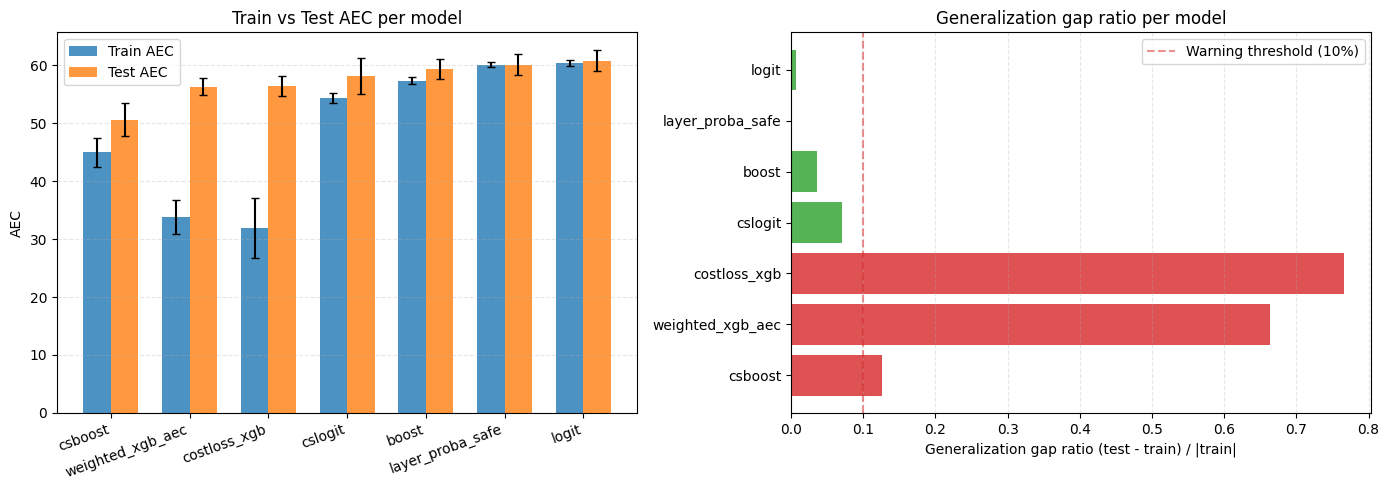

  csboost: gap_ratio=12.64%
  weighted_xgb_aec: gap_ratio=66.39%
  costloss_xgb: gap_ratio=76.57%


In [ ]:
# =============================================================================
# OVERFITTING DIAGNOSTIC: TRAIN vs TEST AEC
# =============================================================================
overfit_df = fold_df.dropna(subset=['train_AEC']).copy()
overfit_summary = overfit_df.groupby('Model').agg(
    train_AEC_mean=('train_AEC', 'mean'),
    test_AEC_mean=('AEC', 'mean'),
    train_AEC_std=('train_AEC', 'std'),
    test_AEC_std=('AEC', 'std'),
).sort_values('test_AEC_mean')
overfit_summary['gap'] = overfit_summary['test_AEC_mean'] - overfit_summary['train_AEC_mean']
overfit_summary['gap_ratio'] = overfit_summary['gap'] / (overfit_summary['train_AEC_mean'].abs() + 1e-12)

print('Overfitting diagnostic (train vs test AEC):')
display(overfit_summary.round(4))

models_ordered = overfit_summary.index.tolist()
x = np.arange(len(models_ordered))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width / 2, overfit_summary['train_AEC_mean'], width, label='Train AEC',
            yerr=overfit_summary['train_AEC_std'], capsize=3, color='tab:blue', alpha=0.8)
axes[0].bar(x + width / 2, overfit_summary['test_AEC_mean'], width, label='Test AEC',
            yerr=overfit_summary['test_AEC_std'], capsize=3, color='tab:orange', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_ordered, rotation=20, ha='right')
axes[0].set_ylabel('AEC')
axes[0].set_title('Train vs Test AEC per model')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

colors = ['tab:red' if g > 0.1 else 'tab:green' for g in overfit_summary['gap_ratio']]
axes[1].barh(models_ordered, overfit_summary['gap_ratio'], color=colors, alpha=0.8)
axes[1].set_xlabel('Generalization gap ratio (test - train) / |train|')
axes[1].set_title('Generalization gap ratio per model')
axes[1].axvline(0.1, color='tab:red', linestyle='--', alpha=0.5, label='Warning threshold (10%)')
axes[1].legend()
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

flagged = overfit_summary[overfit_summary['gap_ratio'] > 0.1]
if len(flagged):
    print(f'WARNING: {len(flagged)} model(s) have >10% generalization gap:')
    for name, row in flagged.iterrows():
        print(f'  {name}: gap_ratio={row["gap_ratio"]:.2%}')
else:
    print('All models have acceptable generalization gap (<10%).')

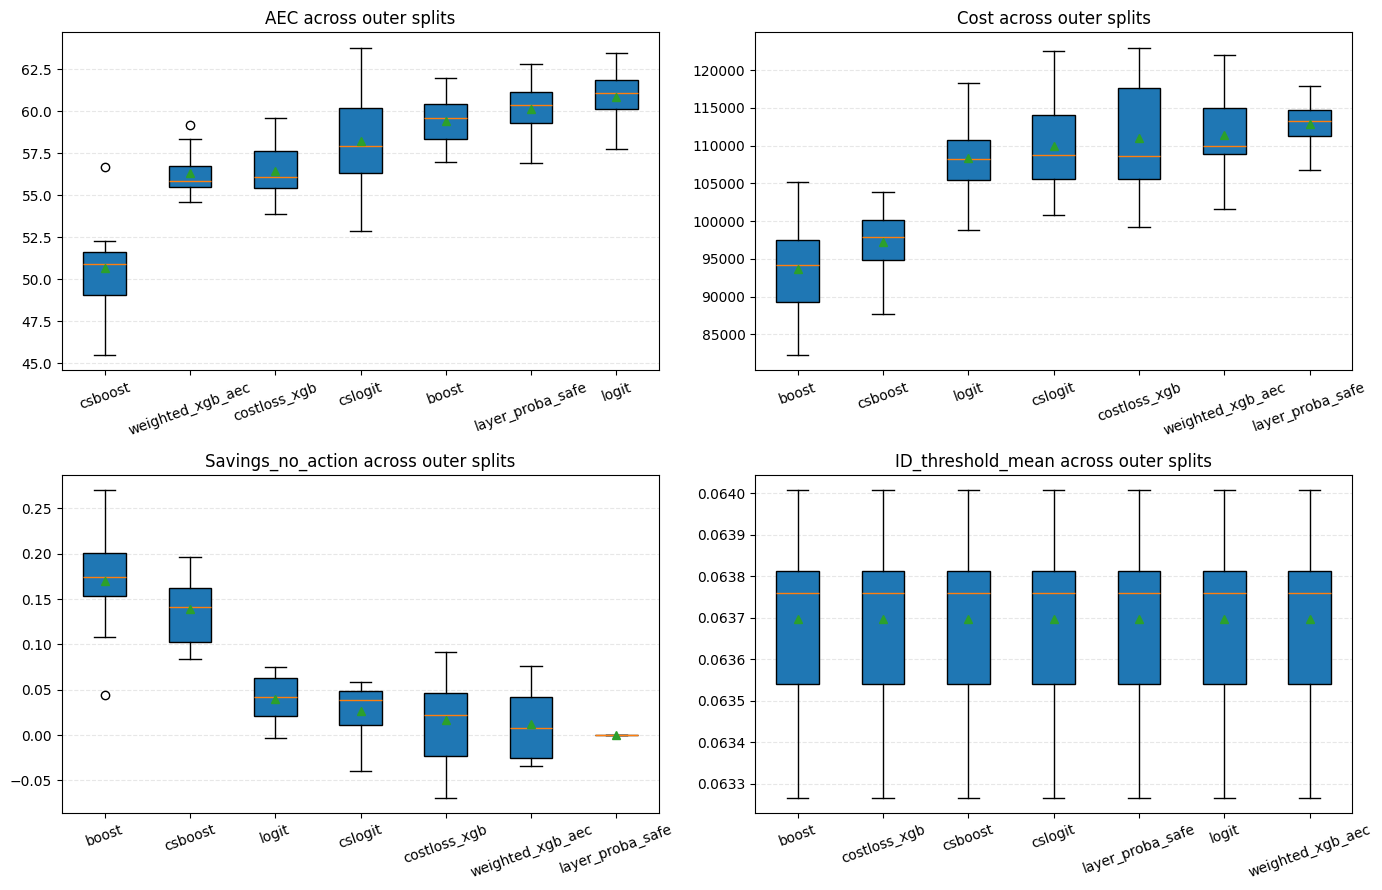

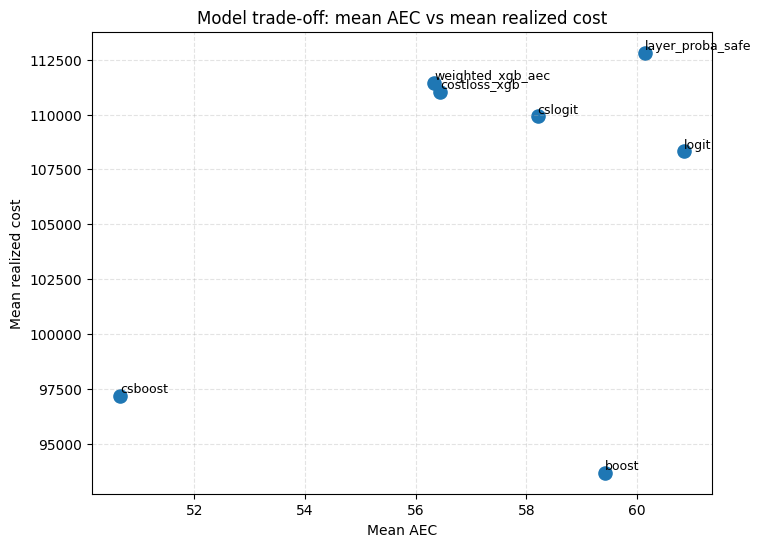

In [ ]:
# =============================================================================
# PERFORMANCE VISUALIZATIONS
# =============================================================================
plot_metrics = ['AEC', 'Cost', 'Savings_no_action', 'ID_threshold_mean']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, metric in zip(axes, plot_metrics):
    order = fold_df.groupby('Model')[metric].mean().sort_values(ascending=(metric not in ['Savings_no_action'])).index.tolist()
    series_list = [fold_df.loc[fold_df['Model'] == model, metric].values for model in order]
    ax.boxplot(series_list, labels=order, patch_artist=True, showmeans=True)
    ax.set_title(f'{metric} across outer splits')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


summary_plot = pd.DataFrame(ALL_RESULTS).T.reset_index().rename(columns={'index': 'Model'})
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(summary_plot['AEC_mean'], summary_plot['Cost_mean'], s=90, color='tab:blue')
for _, row in summary_plot.iterrows():
    ax.text(row['AEC_mean'], row['Cost_mean'], str(row['Model']), fontsize=9, ha='left', va='bottom')
ax.set_xlabel('Mean AEC')
ax.set_ylabel('Mean realized cost')
ax.set_title('Model trade-off: mean AEC vs mean realized cost')
ax.grid(True, linestyle='--', alpha=0.35)
plt.show()


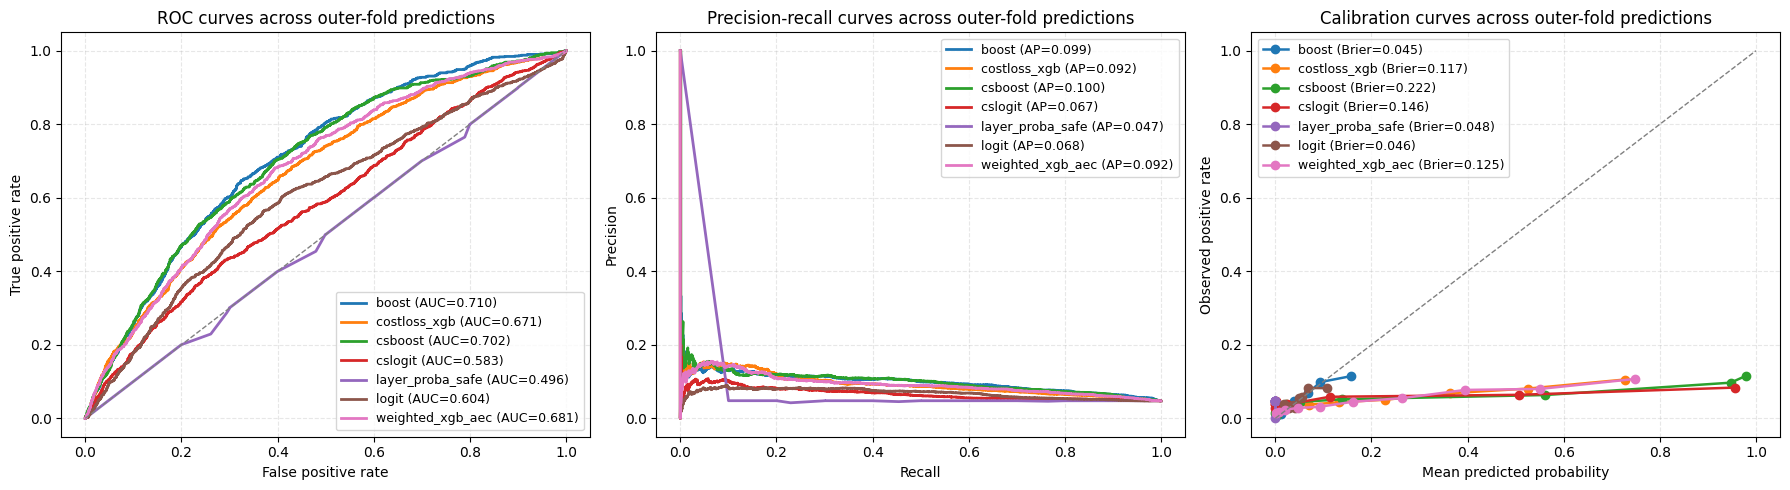

In [ ]:
# =============================================================================
# PROBABILITY-QUALITY VISUALIZATIONS
# =============================================================================
prediction_df = pd.DataFrame(PREDICTION_ROWS)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model_name, model_df in prediction_df.groupby('Model'):
    fpr, tpr, _ = roc_curve(model_df['y_true'], model_df['y_prob'])
    roc_auc = roc_auc_score(model_df['y_true'], model_df['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC curves across outer-fold predictions')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(fontsize=9)

for model_name, model_df in prediction_df.groupby('Model'):
    precision, recall, _ = precision_recall_curve(model_df['y_true'], model_df['y_prob'])
    ap = average_precision_score(model_df['y_true'], model_df['y_prob'])
    axes[1].plot(recall, precision, linewidth=2, label=f'{model_name} (AP={ap:.3f})')

axes[1].set_title('Precision-recall curves across outer-fold predictions')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(fontsize=9)

for model_name, model_df in prediction_df.groupby('Model'):
    frac_pos, mean_pred = calibration_curve(model_df['y_true'], model_df['y_prob'], n_bins=10, strategy='quantile')
    brier = brier_score_loss(model_df['y_true'], model_df['y_prob'])
    axes[2].plot(mean_pred, frac_pos, marker='o', linewidth=1.8, label=f'{model_name} (Brier={brier:.3f})')

axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[2].set_title('Calibration curves across outer-fold predictions')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Observed positive rate')
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


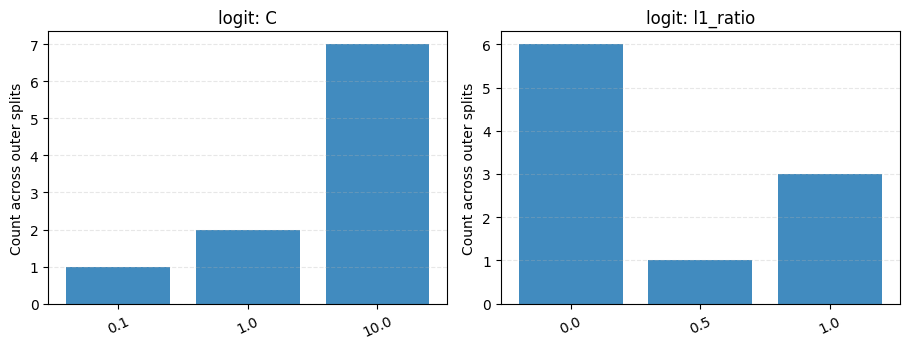

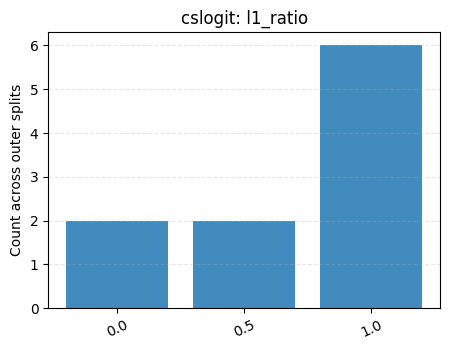

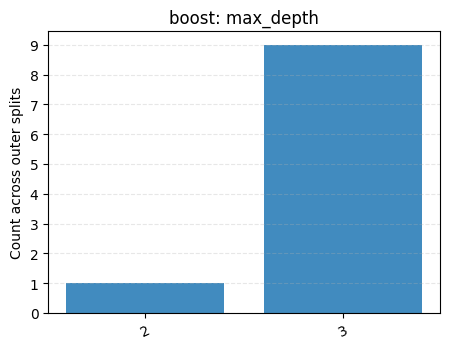

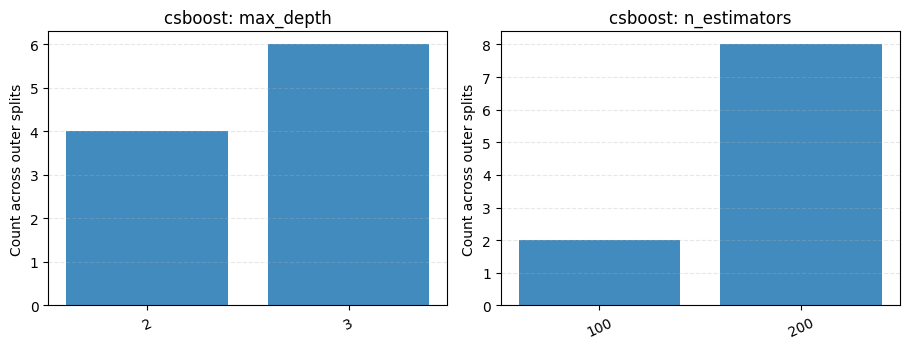

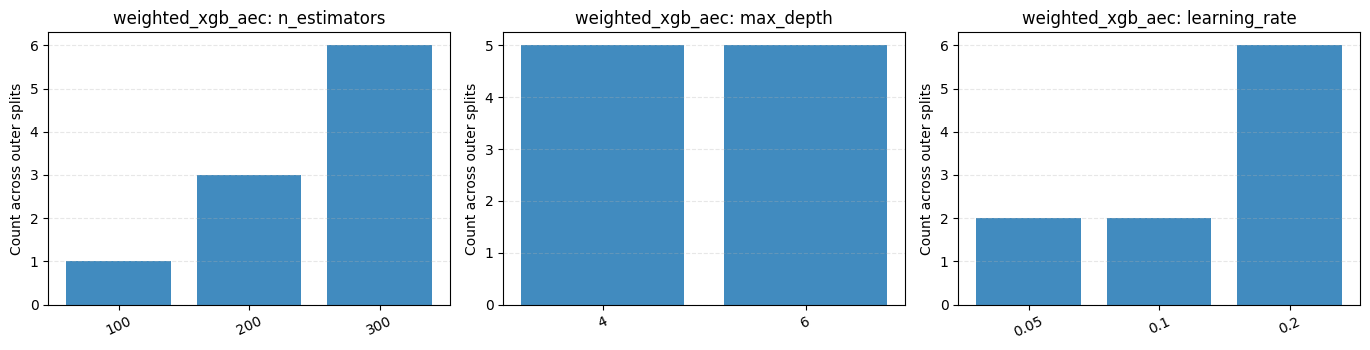

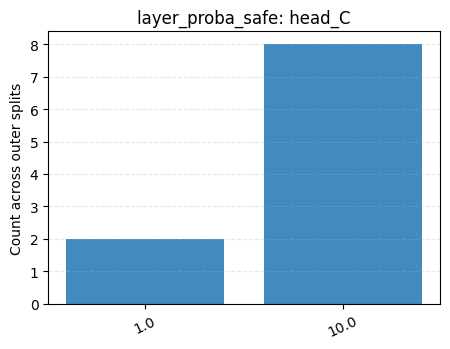

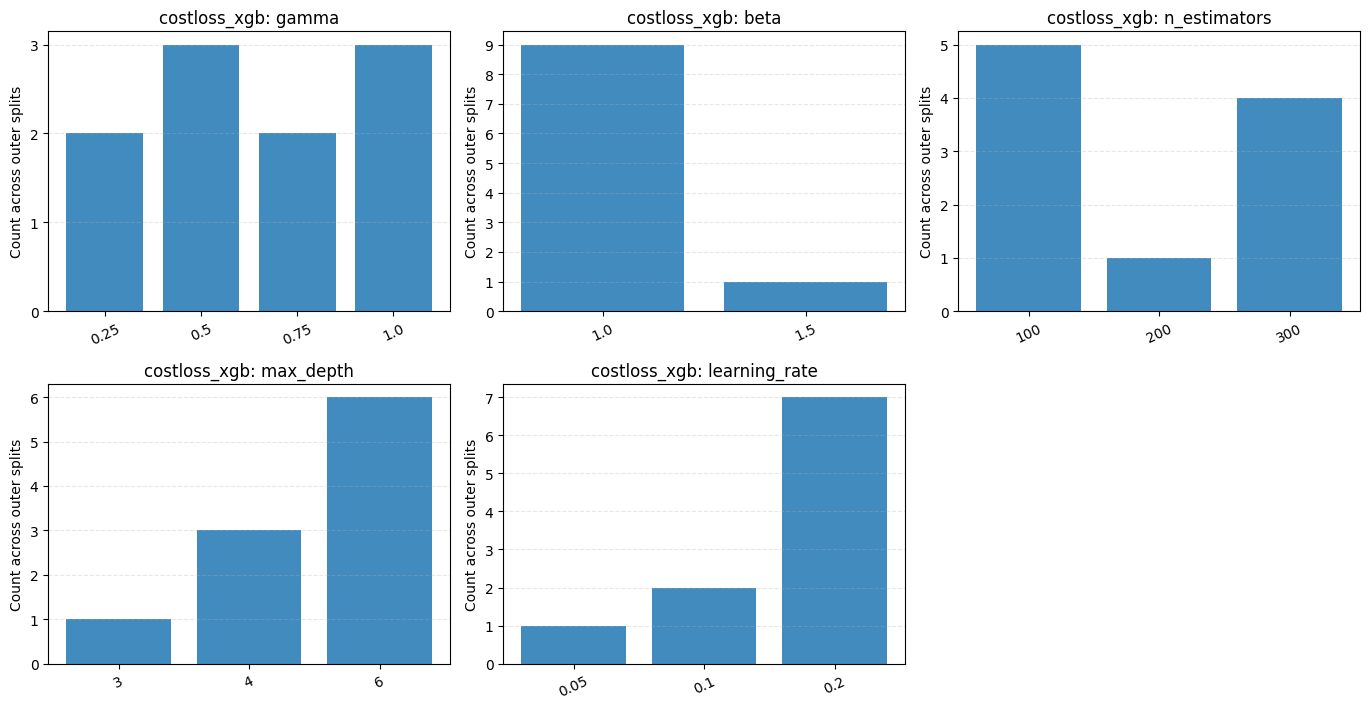

In [ ]:
# =============================================================================
# HYPERPARAMETER SELECTION VISUALIZATIONS
# =============================================================================
def get_hyperparameter_columns(model_name):
    df = pd.DataFrame(FOLD_RESULTS[model_name])
    param_cols = [c for c in df.columns if c.startswith('selected_')]
    return df, param_cols


for model_name in ALL_RESULTS.keys():
    df, param_cols = get_hyperparameter_columns(model_name)
    if not param_cols:
        continue

    non_constant_cols = [col for col in param_cols if df[col].nunique(dropna=False) > 1]
    cols_to_plot = non_constant_cols if non_constant_cols else param_cols

    n_plots = len(cols_to_plot)
    n_cols = min(3, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.6 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, cols_to_plot):
        counts = df[col].astype(str).value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='tab:blue', alpha=0.85)
        ax.set_title(f'{model_name}: {col.replace("selected_", "")}')
        ax.set_ylabel('Count across outer splits')
        ax.tick_params(axis='x', rotation=25)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    for ax in axes[n_plots:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


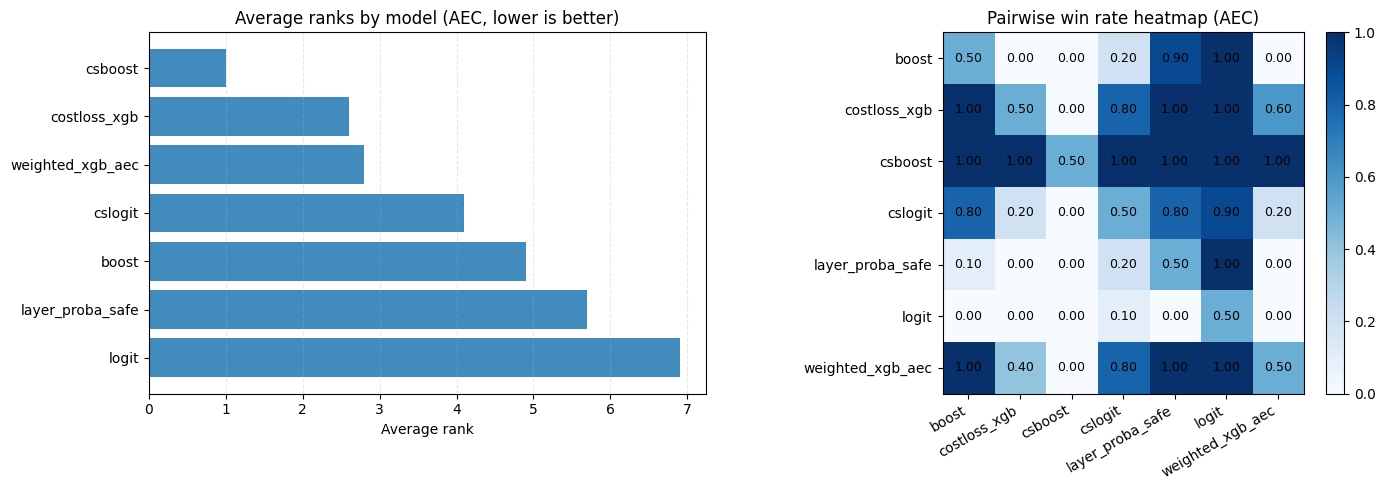

In [ ]:
# =============================================================================
# RANK AND PAIRWISE WIN VISUALIZATIONS
# =============================================================================
PRIMARY_VIS_METRIC = 'AEC'
metric_pivot = fold_df.pivot(index='SplitID', columns='Model', values=PRIMARY_VIS_METRIC).sort_index(axis=1)
rank_table = metric_pivot.rank(axis=1, method='average', ascending=True)
avg_ranks = rank_table.mean(axis=0).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(avg_ranks.index, avg_ranks.values, color='tab:blue', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel('Average rank')
axes[0].set_title(f'Average ranks by model ({PRIMARY_VIS_METRIC}, lower is better)')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

models = list(metric_pivot.columns)
win_rate = pd.DataFrame(index=models, columns=models, dtype=float)
for row_model in models:
    for col_model in models:
        if row_model == col_model:
            win_rate.loc[row_model, col_model] = 0.5
        else:
            paired = metric_pivot[[row_model, col_model]].dropna()
            win_rate.loc[row_model, col_model] = float(np.mean(paired[row_model].values < paired[col_model].values))

im = axes[1].imshow(win_rate.values, cmap='Blues', vmin=0.0, vmax=1.0)
axes[1].set_xticks(range(len(models)))
axes[1].set_yticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=30, ha='right')
axes[1].set_yticklabels(models)
axes[1].set_title(f'Pairwise win rate heatmap ({PRIMARY_VIS_METRIC})')

for i in range(len(models)):
    for j in range(len(models)):
        axes[1].text(j, i, f'{win_rate.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Friedman test for AEC:
  models: ['csboost', 'costloss_xgb', 'weighted_xgb_aec', 'cslogit', 'boost', 'layer_proba_safe', 'logit']
  statistic = 52.5429
  p-value   = 0.000000
  Average ranks (lower is better):


,average_rank
Model,
csboost,1.0
costloss_xgb,2.6
weighted_xgb_aec,2.8
cslogit,4.1
boost,4.9
layer_proba_safe,5.7
logit,6.9


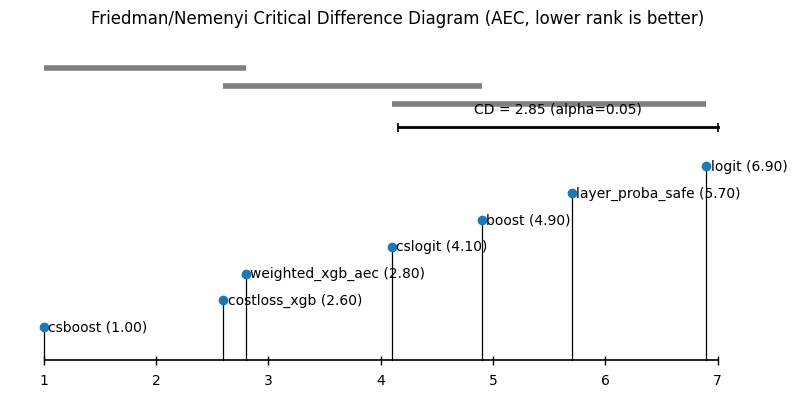

In [ ]:
# =============================================================================
# FRIEDMAN TEST + NEMENYI CRITICAL DIFFERENCE DIAGRAM
# =============================================================================
PRIMARY_METRIC = 'AEC'
ALPHA = 0.05


def friedman_rank_table(df, metric):
    pivot = df.pivot(index='SplitID', columns='Model', values=metric).sort_index(axis=1)
    ranks = pivot.rank(axis=1, method='average', ascending=True)
    avg_ranks = ranks.mean(axis=0).sort_values()
    stat, p_value = scipy_stats.friedmanchisquare(*[pivot[col].values for col in pivot.columns])
    return pivot, ranks, avg_ranks, float(stat), float(p_value)


def nemenyi_cd(n_models, n_splits, alpha=0.05):
    q_alpha = scipy_stats.studentized_range.ppf(1 - alpha, n_models, np.inf) / np.sqrt(2)
    return float(q_alpha * np.sqrt(n_models * (n_models + 1) / (6.0 * n_splits)))


def maximal_nonsignificant_cliques(avg_ranks, cd):
    from itertools import combinations

    model_names = list(avg_ranks.index)
    rank_map = avg_ranks.to_dict()
    all_groups = []

    for r in range(2, len(model_names) + 1):
        for subset in combinations(model_names, r):
            if all(abs(rank_map[a] - rank_map[b]) <= cd + 1e-12 for i, a in enumerate(subset) for b in subset[i + 1:]):
                all_groups.append(subset)

    maximal_groups = []
    for group in all_groups:
        if not any(set(group) < set(other) for other in all_groups):
            maximal_groups.append(group)

    deduped = []
    seen = set()
    for group in maximal_groups:
        if group not in seen:
            deduped.append(group)
            seen.add(group)

    deduped.sort(
        key=lambda group: (
            -(max(rank_map[m] for m in group) - min(rank_map[m] for m in group)),
            -len(group),
            tuple(group),
        )
    )
    return deduped


def plot_cd_diagram(avg_ranks, cd, metric='AEC', alpha=0.05):
    avg_ranks = avg_ranks.sort_values()
    models = list(avg_ranks.index)
    ranks = avg_ranks.values
    n_models = len(models)

    fig_height = 2.2 + 0.35 * n_models
    fig, ax = plt.subplots(figsize=(10, fig_height))

    x_min, x_max = 1, n_models
    axis_y = 0.2
    ax.hlines(axis_y, x_min, x_max, color='black', linewidth=1.2)
    for tick in range(1, n_models + 1):
        ax.vlines(tick, axis_y - 0.03, axis_y + 0.03, color='black', linewidth=1.0)
        ax.text(tick, axis_y - 0.09, f'{tick}', ha='center', va='top', fontsize=10)

    for idx, (model, rank) in enumerate(zip(models, ranks)):
        y = 0.42 + idx * 0.18
        ax.plot([rank, rank], [axis_y, y], color='black', linewidth=0.9)
        ax.scatter(rank, y, s=36, color='tab:blue', zorder=3)
        ax.text(rank + 0.04, y, f'{model} ({rank:.2f})', va='center', ha='left', fontsize=10)

    cd_y = 0.42 + n_models * 0.18 + 0.08
    ax.plot([x_max - cd, x_max], [cd_y, cd_y], color='black', linewidth=2.0)
    ax.vlines([x_max - cd, x_max], cd_y - 0.03, cd_y + 0.03, color='black', linewidth=1.2)
    ax.text(x_max - cd / 2, cd_y + 0.07, f'CD = {cd:.2f} (alpha={alpha:.2f})', ha='center', va='bottom', fontsize=10)

    line_y = cd_y + 0.16
    used_spans = set()
    for clique in maximal_nonsignificant_cliques(avg_ranks, cd):
        clique_ranks = [avg_ranks[m] for m in clique]
        span = (round(min(clique_ranks), 6), round(max(clique_ranks), 6))
        if span in used_spans:
            continue
        used_spans.add(span)
        ax.hlines(line_y, min(clique_ranks), max(clique_ranks), color='tab:gray', linewidth=4)
        line_y += 0.12

    ax.set_xlim(0.7, n_models + 0.6)
    ax.set_ylim(0.0, line_y + 0.12)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f'Friedman/Nemenyi Critical Difference Diagram ({metric}, lower rank is better)')
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_visible(False)
    plt.show()


pivot, rank_table, avg_ranks, friedman_stat, friedman_p = friedman_rank_table(fold_df, PRIMARY_METRIC)
cd = nemenyi_cd(n_models=len(avg_ranks), n_splits=len(pivot), alpha=ALPHA)

print(f'Friedman test for {PRIMARY_METRIC}:')
print(f'  models: {list(avg_ranks.index)}')
print(f'  statistic = {friedman_stat:.4f}')
print(f'  p-value   = {friedman_p:.6f}')
print('  Average ranks (lower is better):')
display(avg_ranks.rename('average_rank').to_frame())

plot_cd_diagram(avg_ranks, cd, metric=PRIMARY_METRIC, alpha=ALPHA)


In [ ]:
# =============================================================================
# PAIRWISE WILCOXON TESTS VS BASELINES (with Holm-Bonferroni correction)
# =============================================================================
ALPHA_PRIMARY = 0.05
ALPHA_SECONDARY = 0.10


def holm_bonferroni(p_values):
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.ones(n, dtype=float)
    cummax = 0.0
    for rank, idx in enumerate(order):
        corrected = p_values[idx] * (n - rank)
        cummax = max(cummax, corrected)
        adjusted[idx] = min(cummax, 1.0)
    return adjusted


def significance_marker(p_value):
    if p_value < ALPHA_PRIMARY:
        return '**'
    if p_value < ALPHA_SECONDARY:
        return '*'
    return ''


def rank_biserial_correlation(x, y):
    """Matched-pairs rank-biserial correlation (effect size for Wilcoxon)."""
    diff = x - y
    diff = diff[diff != 0]
    n = len(diff)
    if n == 0:
        return 0.0
    abs_diff = np.abs(diff)
    ranks = scipy_stats.rankdata(abs_diff)
    r_plus = np.sum(ranks[diff > 0])
    r_minus = np.sum(ranks[diff < 0])
    return float((r_plus - r_minus) / (r_plus + r_minus)) if (r_plus + r_minus) > 0 else 0.0


def pairwise_wilcoxon_vs_baselines(df, target_models, baseline_models, metric):
    pivot = df.pivot(index='SplitID', columns='Model', values=metric)
    rows = []
    lower_is_better = metric in ['AEC', 'Cost', 'Brier']

    for target in target_models:
        for baseline in baseline_models:
            paired = pivot[[target, baseline]].dropna()
            x = paired[target].values
            y = paired[baseline].values
            try:
                stat, p_value = scipy_stats.wilcoxon(x, y, zero_method='wilcox', alternative='two-sided')
                stat = float(stat)
                p_value = float(p_value)
            except ValueError:
                stat = np.nan
                p_value = 1.0

            target_mean = float(np.mean(x))
            baseline_mean = float(np.mean(y))
            mean_diff = target_mean - baseline_mean
            better_than_baseline = mean_diff < 0 if lower_is_better else mean_diff > 0
            r_rb = rank_biserial_correlation(x, y)

            rows.append({
                'metric': metric,
                'target': target,
                'baseline': baseline,
                'target_mean': target_mean,
                'baseline_mean': baseline_mean,
                'mean_diff': mean_diff,
                'wilcoxon_stat': stat,
                'p_value': p_value,
                'effect_size_r': r_rb,
                'better_than_baseline': better_than_baseline,
            })

    result_df = pd.DataFrame(rows)
    raw_p = result_df['p_value'].values
    adjusted_p = holm_bonferroni(raw_p)
    result_df['p_adjusted'] = adjusted_p
    result_df['sig_marker'] = result_df['p_adjusted'].apply(significance_marker)
    result_df['result'] = result_df.apply(
        lambda r: (f"{r['sig_marker']} better" if r['better_than_baseline'] else f"{r['sig_marker']} worse")
        if r['sig_marker'] else 'n.s.',
        axis=1,
    )
    return result_df


weighted_models = ['teacher_csboost']
baseline_models = ['logit', 'cslogit', 'boost', 'csboost']

WILCOXON_METRICS = [
    'AEC', 'Cost', 'Brier', 'AUROC', 'AP', 'F1',
    'Savings_no_action', 'Savings_best_trivial', 'Spearman',
]

wilcoxon_display_cols = ['target', 'baseline', 'target_mean', 'baseline_mean',
                         'mean_diff', 'effect_size_r', 'p_value', 'p_adjusted', 'result']

all_wilcoxon = {}
for metric in WILCOXON_METRICS:
    wdf = pairwise_wilcoxon_vs_baselines(fold_df, weighted_models, baseline_models, metric)
    all_wilcoxon[metric] = wdf
    direction = '(lower is better)' if metric in ['AEC', 'Cost', 'Brier'] else '(higher is better)'
    print(f'\nWilcoxon signed-rank tests — {metric} {direction}  (Holm-Bonferroni corrected)')
    print('** p_adj < 0.05 | * p_adj < 0.10 | n.s. = not significant')
    display(wdf.sort_values(['target', 'baseline'])[wilcoxon_display_cols])


Wilcoxon signed-rank tests vs baselines for AEC (Holm-Bonferroni corrected)
Markers: ** p_adj < 0.05, * p_adj < 0.10, n.s. = not significant
effect_size_r = matched-pairs rank-biserial correlation (-1..+1)


,target,baseline,target_mean,baseline_mean,mean_diff,effect_size_r,p_value,p_adjusted,result
10,costloss_xgb,boost,56.446089,59.419009,-2.972920,-1.000000,0.001953,0.023438,** better
11,costloss_xgb,csboost,56.446089,50.657383,5.788706,1.000000,0.001953,0.023438,** worse
9,costloss_xgb,cslogit,56.446089,58.205073,-1.758984,-0.745455,0.037109,0.074219,* better
8,costloss_xgb,logit,56.446089,60.846228,-4.400139,-1.000000,0.001953,0.023438,** better
6,layer_proba_safe,boost,60.143258,59.419009,0.724249,0.963636,0.003906,0.023438,** worse
7,layer_proba_safe,csboost,60.143258,50.657383,9.485875,1.000000,0.001953,0.023438,** worse
5,layer_proba_safe,cslogit,60.143258,58.205073,1.938185,0.890909,0.009766,0.029297,** worse
4,layer_proba_safe,logit,60.143258,60.846228,-0.702970,-1.000000,0.001953,0.023438,** better
2,weighted_xgb_aec,boost,56.334976,59.419009,-3.084033,-1.000000,0.001953,0.023438,** better
3,weighted_xgb_aec,csboost,56.334976,50.657383,5.677593,1.000000,0.001953,0.023438,** worse


Wilcoxon signed-rank tests vs baselines for Cost (Holm-Bonferroni corrected)
Markers: ** p_adj < 0.05, * p_adj < 0.10, n.s. = not significant
effect_size_r = matched-pairs rank-biserial correlation (-1..+1)


,target,baseline,target_mean,baseline_mean,mean_diff,effect_size_r,p_value,p_adjusted,result
10,costloss_xgb,boost,111042.953081,93672.269680,17370.683401,1.000000,0.001953,0.023438,** worse
11,costloss_xgb,csboost,111042.953081,97185.508812,13857.444270,1.000000,0.001953,0.023438,** worse
9,costloss_xgb,cslogit,111042.953081,109932.087405,1110.865677,0.236364,0.556641,0.750000,n.s.
8,costloss_xgb,logit,111042.953081,108322.891976,2720.061105,0.527273,0.160156,0.480469,n.s.
6,layer_proba_safe,boost,112817.142865,93672.269680,19144.873185,1.000000,0.001953,0.023438,** worse
7,layer_proba_safe,csboost,112817.142865,97185.508812,15631.634054,1.000000,0.001953,0.023438,** worse
5,layer_proba_safe,cslogit,112817.142865,109932.087405,2885.055461,0.745455,0.037109,0.185547,n.s.
4,layer_proba_safe,logit,112817.142865,108322.891976,4494.250889,0.963636,0.003906,0.023438,** worse
2,weighted_xgb_aec,boost,111456.806505,93672.269680,17784.536825,1.000000,0.001953,0.023438,** worse
3,weighted_xgb_aec,csboost,111456.806505,97185.508812,14271.297694,1.000000,0.001953,0.023438,** worse
